In [29]:
import requests
import bs4
import re
from sys import stdout
from gensim.models import KeyedVectors
import gensim.downloader as api
import matplotlib.pyplot as plt
from os.path import expanduser
from time import perf_counter
from functools import lru_cache

In [2]:
class IllegalArgumentError(ValueError):
    pass

MODEL_NAME = "word2vec-google-news-300"

In [4]:
stdout.write(f"⏳ Loading {MODEL_NAME}... ")
stdout.flush()
try:
    starting_time_model = perf_counter()
    model = KeyedVectors.load_word2vec_format(expanduser(f"~/gensim-data/{MODEL_NAME}/{MODEL_NAME}.gz"), binary=True)
    ending_time_model = perf_counter()
except Exception as e:
    stdout.write(f"\nError loading model: {e}\n")
    stdout.flush()
    model = api.load(MODEL_NAME)
print("Model loaded successfully. ✅")
print(f"(loaded from local file in {ending_time_model - starting_time_model:.2f} seconds)")

⏳ Loading word2vec-google-news-300... Model loaded successfully. ✅
(loaded from local file in 113.47 seconds)


In [5]:
@lru_cache()
def cosine_sim(title1, title2):
	avg_v1 = get_word_embedding(title1)
	avg_v2 = get_word_embedding(title2)
	if avg_v1 is None:
		return float('inf')
	return 1 - model.cosine_similarities(avg_v1, [avg_v2])[0]

def is_dest_embedding_possible(title):
	words = title.split("_")
	for word in words:
		if word in model:
			return True
		elif word.lower() in model:
			return True
	return False

def get_word_embedding(phrase):
	words = phrase.split("_")
	sum_v = [0.0] * model.vector_size
	n_words = 0
	for word in words:
		if word in model:
			sum_v += model.get_vector(word)
			n_words += 1
		elif word.lower() in model:
			sum_v += model.get_vector(word.lower())
			n_words += 1
	if n_words == 0:
		return None
	avg_v = sum_v / n_words
	return avg_v

In [18]:
def check_links(origin_link, dest_link):
    if re.match(r"https://[a-z]{2}.wikipedia.org/wiki/", origin_link) is None:
        raise IllegalArgumentError("Origin link is not a Wikipedia link! Valid wiki link example: https://<language>.wikipedia.org/wiki/<title>")
    if re.match(r"https://[a-z]{2}.wikipedia.org/wiki/", dest_link) is None:
        raise IllegalArgumentError("Destination link is not a Wikipedia link! Valid wiki link example: https://<language>.wikipedia.org/wiki/<title>")
    origin_title = origin_link.split("/wiki/")[1]
    dest_title = dest_link.split("/wiki/")[1]
    lang = origin_link.split("/")[2].split(".")[0]
    if lang != dest_link.split("/")[2].split(".")[0]:
        raise IllegalArgumentError("Origin and destination links must be in the same language Wikipedia!")
    print(f"GAME SETTINGS ⚙️\nOrigin: {origin_link}\nDestination: {dest_link}\nLanguage: {lang}\n" + "-"*120)
    session = requests.Session()
    session.headers.update({
        "User-Agent": "MyPythonWikipediaClient/1.0",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    })
    origin_page = session.get(origin_link)
    if origin_page.status_code != 200:
        raise IllegalArgumentError("Origin page does not exist!")
    dest_page = session.get(dest_link)
    if dest_page.status_code != 200:
        raise IllegalArgumentError("Destination page does not exist!")

In [42]:
def plot_distance_history(distances):
    plt.figure(figsize=(10, 6))
    plt.plot(distances, marker='o')
    plt.ylim(top=1, bottom=0)
    plt.title('Distance to Target Over Time')
    plt.xlabel('Number of Links Traversed')
    plt.ylabel('Cosine Distance to Target')
    plt.grid(True)
    plt.show()

In [39]:
def play(origin_link, dest_link, plot_distance = True):
    origin_title = origin_link.split("/wiki/")[1]
    dest_title = dest_link.split("/wiki/")[1]
    lang = origin_link.split("/")[2].split(".")[0]
    num_links = 1
    history = [origin_title]
    min_distance = cosine_sim(origin_title, dest_title)
    distances = [min_distance]
    found = False
    curr_link = origin_link
    starting_time = perf_counter()
    visited_links = set()
    visited_links.add(origin_link)
    session = requests.Session()
    session.headers.update({
		"User-Agent": "MyPythonWikipediaClient/1.0",
		"Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
	})
    while not found:
        print(f"CURRENT PAGE: {curr_link:70}\tDistance to target: {min_distance:.10f}")
        curr_page = session.get(curr_link)
        soup = bs4.BeautifulSoup(curr_page.text, 'html.parser')
        links = soup.find_all('a', href=True) # get every link in <a>
        found = False
        min_distance = float('inf')
        next_link = None
        for link in links:
            href = link['href']
            if href.startswith("/wiki/") and ':' not in href:
                full_link = f"https://{lang}.wikipedia.org{href}"
                if full_link in visited_links:
                    continue
                if full_link == dest_link:
                    history.append(dest_title)
                    distances.append(0.0)
                    print(f"CURRENT PAGE: {full_link:70}\tDistance to target: {0.0:.10f}\n" + "-"*120)
                    ending_time = perf_counter()
                    found = True
                    break
                curr_title = href.split("/wiki/")[1]
                distance = cosine_sim(curr_title, dest_title)
                if distance < min_distance:
                    min_distance = distance
                    next_link = full_link
        else:
            if next_link is None:
                raise Exception("No valid links found on the page! 💀")
            history.append(next_link.split("/wiki/")[1])
            visited_links.add(next_link)
            distances.append(min_distance)
            num_links += 1
            curr_link = next_link
    if plot_distance:
        plot_distance_history(distances)
    print("\n\nAI WINS! 🎉")
    print(f"Number of links traversed: {num_links}")
    print(f"Total time taken: {ending_time - starting_time:.3f} seconds")

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Barack_Obama
Destination: https://en.wikipedia.org/wiki/Artificial_intelligence
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Barack_Obama                            	Distance to target: 0.9210387865
CURRENT PAGE: https://en.wikipedia.org/wiki/Central_Intelligence_Agency             	Distance to target: 0.5758052835
CURRENT PAGE: https://en.wikipedia.org/wiki/Open-source_intelligence                	Distance to target: 0.2878684242
CURRENT PAGE: https://en.wikipedia.org/wiki/All-source_intelligence                 	Distance to target: 0.2878684242
CURRENT PAGE: https://en.wikipedia.org/wiki/Military_intelligence                   	Distance to target: 0.3427541986
CURRENT PAGE: https://en.wikipedia.org/wiki/Artificial_intelligence_arms_race       	Distance to target: 0.2006176836
CURRENT PAGE: https://e

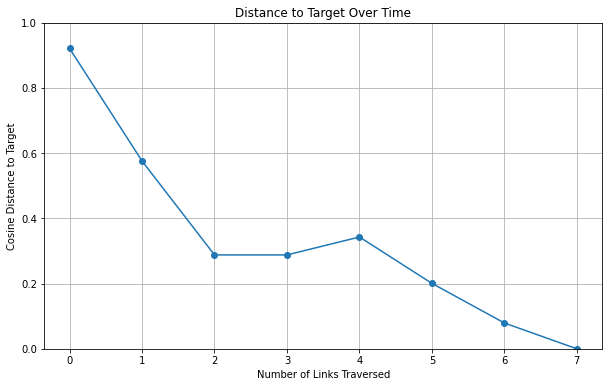



AI WINS! 🎉
Number of links traversed: 7
Total time taken: 4.375 seconds


In [43]:
origin_link = "https://en.wikipedia.org/wiki/Barack_Obama"
dest_link = "https://en.wikipedia.org/wiki/Artificial_intelligence"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Julius_Caesar
Destination: https://en.wikipedia.org/wiki/Quantum_computing
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Julius_Caesar                           	Distance to target: 0.9162896194
CURRENT PAGE: https://en.wikipedia.org/wiki/Temple_of_Jupiter_Optimus_Maximus       	Distance to target: 0.6647084015
CURRENT PAGE: https://en.wikipedia.org/wiki/Cornice                                 	Distance to target: 0.6844759946
CURRENT PAGE: https://en.wikipedia.org/wiki/Architecture                            	Distance to target: 0.6935821410
CURRENT PAGE: https://en.wikipedia.org/wiki/Design_computing                        	Distance to target: 0.3268308459
CURRENT PAGE: https://en.wikipedia.org/wiki/Spatial_computing                       	Distance to target: 0.2800512257
CURRENT PAGE: https://en.wik

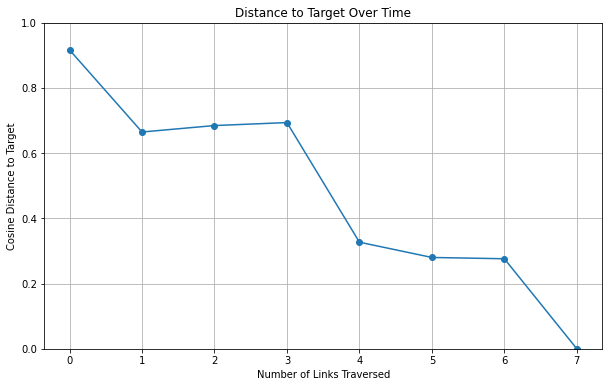



AI WINS! 🎉
Number of links traversed: 7
Total time taken: 2.753 seconds


In [44]:
origin_link = "https://en.wikipedia.org/wiki/Julius_Caesar"
dest_link = "https://en.wikipedia.org/wiki/Quantum_computing"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Taylor_Swift
Destination: https://en.wikipedia.org/wiki/Game_theory
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Taylor_Swift                            	Distance to target: 0.9343295696
CURRENT PAGE: https://en.wikipedia.org/wiki/End_Game_(song)                         	Distance to target: 0.3910139299
CURRENT PAGE: https://en.wikipedia.org/wiki/Snake_(video_game_genre)                	Distance to target: 0.5796189257
CURRENT PAGE: https://en.wikipedia.org/wiki/Roguelike_deck-building_game            	Distance to target: 0.5379901959
CURRENT PAGE: https://en.wikipedia.org/wiki/Shooter_game                            	Distance to target: 0.5380421890
CURRENT PAGE: https://en.wikipedia.org/wiki/Galaxy_Game                             	Distance to target: 0.3964886517
CURRENT PAGE: https://en.wikipedia.

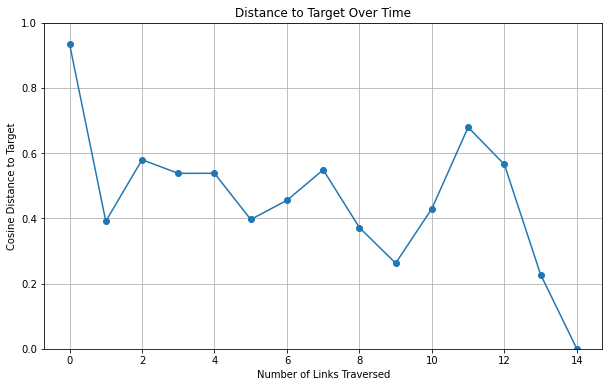



AI WINS! 🎉
Number of links traversed: 14
Total time taken: 5.047 seconds


In [45]:
origin_link = "https://en.wikipedia.org/wiki/Taylor_Swift"
dest_link = "https://en.wikipedia.org/wiki/Game_theory"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Photosynthesis
Destination: https://en.wikipedia.org/wiki/Pizza
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Photosynthesis                          	Distance to target: 0.9408726346
CURRENT PAGE: https://en.wikipedia.org/wiki/Nut_(fruit)                             	Distance to target: 0.6163731266
CURRENT PAGE: https://en.wikipedia.org/wiki/Snack                                   	Distance to target: 0.5101689811
CURRENT PAGE: https://en.wikipedia.org/wiki/Pizza                                   	Distance to target: 0.0000000000
------------------------------------------------------------------------------------------------------------------------


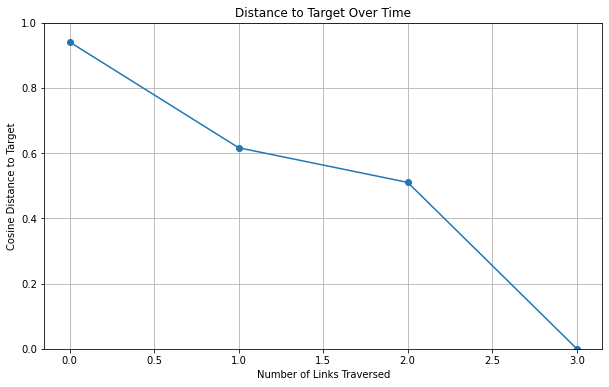



AI WINS! 🎉
Number of links traversed: 3
Total time taken: 1.442 seconds


In [46]:
origin_link = "https://en.wikipedia.org/wiki/Photosynthesis"
dest_link = "https://en.wikipedia.org/wiki/Pizza"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Pizza
Destination: https://en.wikipedia.org/wiki/Photosynthesis
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Pizza                                   	Distance to target: 0.9408726346
CURRENT PAGE: https://en.wikipedia.org/wiki/Denaturation_(biochemistry)             	Distance to target: 0.5937027524
CURRENT PAGE: https://en.wikipedia.org/wiki/Biosynthesis                            	Distance to target: 0.4503778753
CURRENT PAGE: https://en.wikipedia.org/wiki/Biogeochemistry                         	Distance to target: 0.4487000457
CURRENT PAGE: https://en.wikipedia.org/wiki/Organic_synthesis                       	Distance to target: 0.4847333163
CURRENT PAGE: https://en.wikipedia.org/wiki/Chiral_synthesis                        	Distance to target: 0.4486642606
CURRENT PAGE: https://en.wikipedia.org/

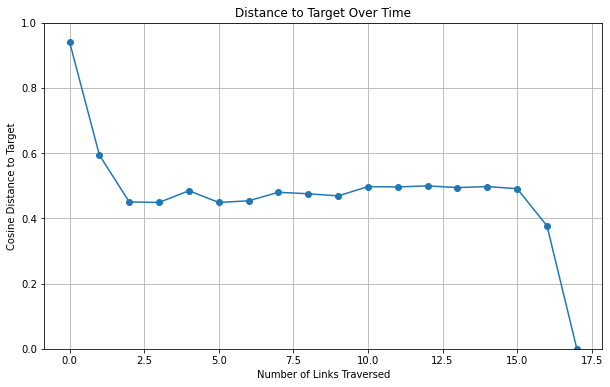



AI WINS! 🎉
Number of links traversed: 17
Total time taken: 8.003 seconds


In [53]:
origin_link = "https://en.wikipedia.org/wiki/Pizza"
dest_link = "https://en.wikipedia.org/wiki/Photosynthesis"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Mount_Everest
Destination: https://en.wikipedia.org/wiki/Marvel_Cinematic_Universe
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Mount_Everest                           	Distance to target: 0.8929345381
CURRENT PAGE: https://en.wikipedia.org/wiki/Snowman_Trek                            	Distance to target: 0.6091221162
CURRENT PAGE: https://en.wikipedia.org/wiki/Altitude_sickness                       	Distance to target: 0.8093565491
CURRENT PAGE: https://en.wikipedia.org/wiki/Google_Books                            	Distance to target: 0.6515734819
CURRENT PAGE: https://en.wikipedia.org/wiki/Grimoire                                	Distance to target: 0.5280050661
CURRENT PAGE: https://en.wikipedia.org/wiki/Shapeshifting                           	Distance to target: 0.4575548355
CURRENT PAGE: https:

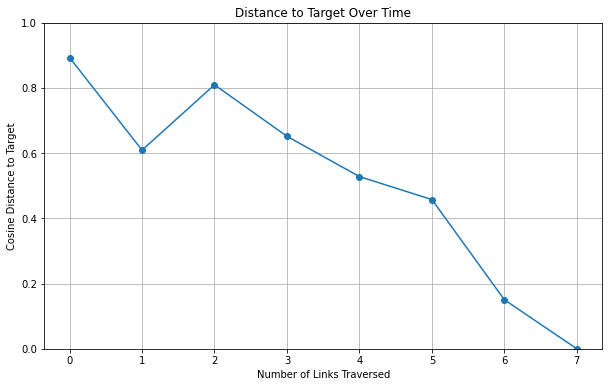



AI WINS! 🎉
Number of links traversed: 7
Total time taken: 3.257 seconds


In [47]:
origin_link = "https://en.wikipedia.org/wiki/Mount_Everest"
dest_link = "https://en.wikipedia.org/wiki/Marvel_Cinematic_Universe"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Wolf
Destination: https://en.wikipedia.org/wiki/Artificial_neural_network
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Wolf                                    	Distance to target: 0.8548010053
CURRENT PAGE: https://en.wikipedia.org/wiki/Phylogenetic                            	Distance to target: 0.5479170677
CURRENT PAGE: https://en.wikipedia.org/wiki/Phylogenetic_network                    	Distance to target: 0.3816456892
CURRENT PAGE: https://en.wikipedia.org/wiki/Molecular_phylogenetics                 	Distance to target: 0.5199095030
CURRENT PAGE: https://en.wikipedia.org/wiki/Inferring_horizontal_gene_transfer#Explicit_phylogenetic_methods	Distance to target: 0.4687436706
CURRENT PAGE: https://en.wikipedia.org/wiki/Horizontal_gene_transfer_in_evolution   	Distance to target: 0.5437539813
CURRE

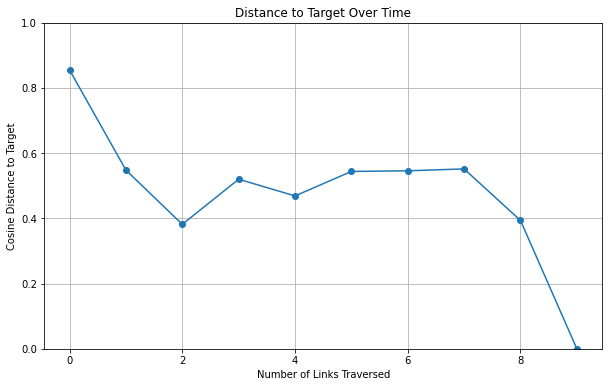



AI WINS! 🎉
Number of links traversed: 9
Total time taken: 3.632 seconds


In [48]:
origin_link = "https://en.wikipedia.org/wiki/Wolf"
dest_link = "https://en.wikipedia.org/wiki/Artificial_neural_network"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Dolphin
Destination: https://en.wikipedia.org/wiki/Internet
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Dolphin                                 	Distance to target: 0.9701796363
CURRENT PAGE: https://en.wikipedia.org/wiki/YouTube                                 	Distance to target: 0.5176808096
CURRENT PAGE: https://en.wikipedia.org/wiki/Internet                                	Distance to target: 0.0000000000
------------------------------------------------------------------------------------------------------------------------


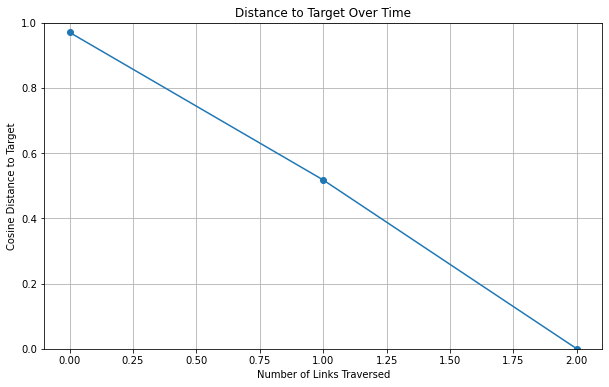



AI WINS! 🎉
Number of links traversed: 2
Total time taken: 1.705 seconds


In [49]:
origin_link = "https://en.wikipedia.org/wiki/Dolphin"
dest_link = "https://en.wikipedia.org/wiki/Internet"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/SpongeBob_SquarePants
Destination: https://en.wikipedia.org/wiki/Cryptography
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/SpongeBob_SquarePants                   	Distance to target: 1.0061420036
CURRENT PAGE: https://en.wikipedia.org/wiki/Application_software                    	Distance to target: 0.6183540944
CURRENT PAGE: https://en.wikipedia.org/wiki/Proprietary_software                    	Distance to target: 0.5921196910
CURRENT PAGE: https://en.wikipedia.org/wiki/Trusted_Computing                       	Distance to target: 0.4846983209
CURRENT PAGE: https://en.wikipedia.org/wiki/Public-key_cryptography                 	Distance to target: 0.3661613989
CURRENT PAGE: https://en.wikipedia.org/wiki/Symmetric_cryptography                  	Distance to target: 0.3449742432
CURRENT PAGE: https://en.

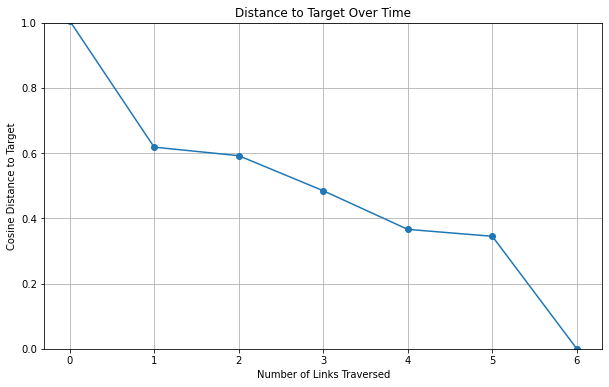



AI WINS! 🎉
Number of links traversed: 6
Total time taken: 2.501 seconds


In [54]:
origin_link = "https://en.wikipedia.org/wiki/SpongeBob_SquarePants"
dest_link = "https://en.wikipedia.org/wiki/Cryptography"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Banana
Destination: https://en.wikipedia.org/wiki/Quantum_field_theory
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Banana                                  	Distance to target: 0.9340414758
CURRENT PAGE: https://en.wikipedia.org/wiki/Genetic_engineering                     	Distance to target: 0.6960934048
CURRENT PAGE: https://en.wikipedia.org/wiki/Theory                                  	Distance to target: 0.5304062054
CURRENT PAGE: https://en.wikipedia.org/wiki/Quantum_field_theory                    	Distance to target: 0.0000000000
------------------------------------------------------------------------------------------------------------------------


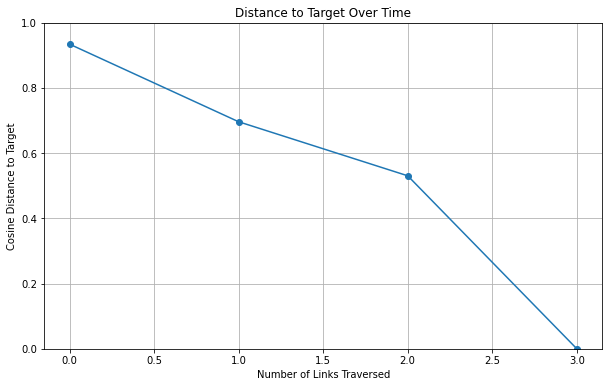



AI WINS! 🎉
Number of links traversed: 3
Total time taken: 1.672 seconds


In [55]:
origin_link = "https://en.wikipedia.org/wiki/Banana"
dest_link = "https://en.wikipedia.org/wiki/Quantum_field_theory"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Cheeseburger
Destination: https://en.wikipedia.org/wiki/General_relativity
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Cheeseburger                            	Distance to target: 0.9866283733
CURRENT PAGE: https://en.wikipedia.org/wiki/History_of_the_hamburger_in_the_United_States	Distance to target: 0.7441787464
CURRENT PAGE: https://en.wikipedia.org/wiki/History_of_the_hamburger                	Distance to target: 0.7927735390
CURRENT PAGE: https://en.wikipedia.org/wiki/Cornell_University_School_of_Hotel_Administration	Distance to target: 0.7503523289
CURRENT PAGE: https://en.wikipedia.org/wiki/Administrative_Science_Quarterly        	Distance to target: 0.6850141637
CURRENT PAGE: https://en.wikipedia.org/wiki/Journal_of_Empirical_Legal_Studies      	Distance to target: 0.7309796841
CURRENT PAGE: 

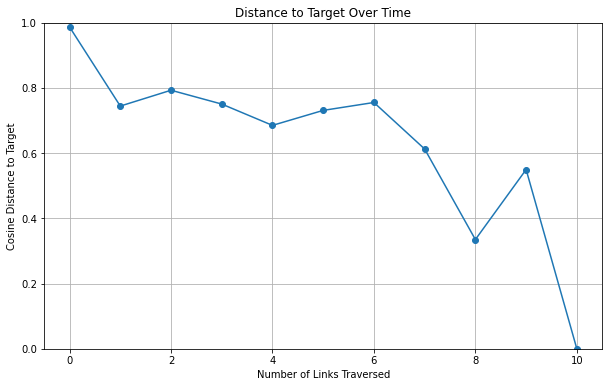



AI WINS! 🎉
Number of links traversed: 10
Total time taken: 3.635 seconds


In [56]:
origin_link = "https://en.wikipedia.org/wiki/Cheeseburger"
dest_link = "https://en.wikipedia.org/wiki/General_relativity"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Teddy_bear
Destination: https://en.wikipedia.org/wiki/Hyperbolic_geometry
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Teddy_bear                              	Distance to target: 0.9339843533
CURRENT PAGE: https://en.wikipedia.org/wiki/Imaginary_(film)                        	Distance to target: 0.6856394408
CURRENT PAGE: https://en.wikipedia.org/wiki/Weighted_arithmetic_mean                	Distance to target: 0.5792199474
CURRENT PAGE: https://en.wikipedia.org/wiki/Weighted_geometric_mean                 	Distance to target: 0.4093356791
CURRENT PAGE: https://en.wikipedia.org/wiki/Weighted_harmonic_mean                  	Distance to target: 0.4782109250
CURRENT PAGE: https://en.wikipedia.org/wiki/Probabilistic_design                    	Distance to target: 0.3931759879
CURRENT PAGE: https://en.wiki

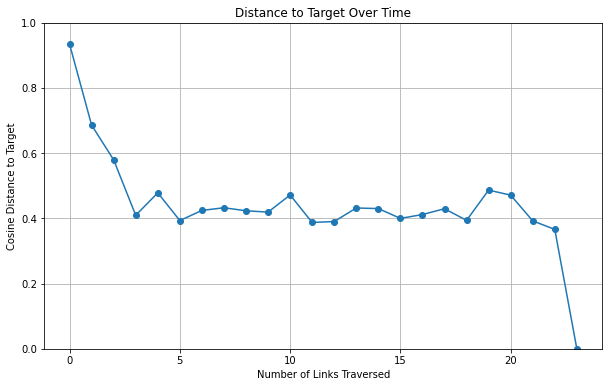



AI WINS! 🎉
Number of links traversed: 23
Total time taken: 13.482 seconds


In [57]:
origin_link = "https://en.wikipedia.org/wiki/Teddy_bear"
dest_link = "https://en.wikipedia.org/wiki/Hyperbolic_geometry"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Toilet_paper
Destination: https://en.wikipedia.org/wiki/Entropy
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Toilet_paper                            	Distance to target: 0.8343460505
CURRENT PAGE: https://en.wikipedia.org/wiki/Defecation                              	Distance to target: 0.6369664796
CURRENT PAGE: https://en.wikipedia.org/wiki/Reverse_peristalsis                     	Distance to target: 0.6336454232
CURRENT PAGE: https://en.wikipedia.org/wiki/Peristalsis                             	Distance to target: 0.7469392062
CURRENT PAGE: https://en.wikipedia.org/wiki/Serotonin                               	Distance to target: 0.6205530372
CURRENT PAGE: https://en.wikipedia.org/wiki/Cyclic_3-hydroxymelatonin               	Distance to target: 0.5565139434
CURRENT PAGE: https://en.wikipedia.org/

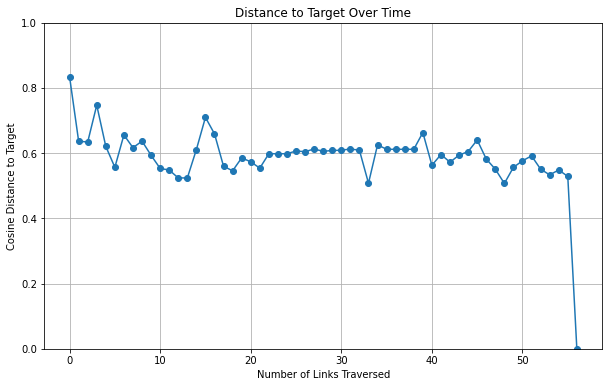



AI WINS! 🎉
Number of links traversed: 56
Total time taken: 27.940 seconds


In [58]:
origin_link = "https://en.wikipedia.org/wiki/Toilet_paper"
dest_link = "https://en.wikipedia.org/wiki/Entropy"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Dark_matter
Destination: https://en.wikipedia.org/wiki/Toilet
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Dark_matter                             	Distance to target: 0.8368819637
CURRENT PAGE: https://en.wikipedia.org/wiki/History_of_the_Big_Bang_theory          	Distance to target: 0.6999016661
CURRENT PAGE: https://en.wikipedia.org/wiki/Big_Bang                                	Distance to target: 0.7247263449
CURRENT PAGE: https://en.wikipedia.org/wiki/The_Big_Bang_Theory                     	Distance to target: 0.6984175883
CURRENT PAGE: https://en.wikipedia.org/wiki/The_Hot_Troll_Deviation                 	Distance to target: 0.6658253916
CURRENT PAGE: https://en.wikipedia.org/wiki/The_Love_Car_Displacement               	Distance to target: 0.6827665411
CURRENT PAGE: https://en.wikipedia.org/wi

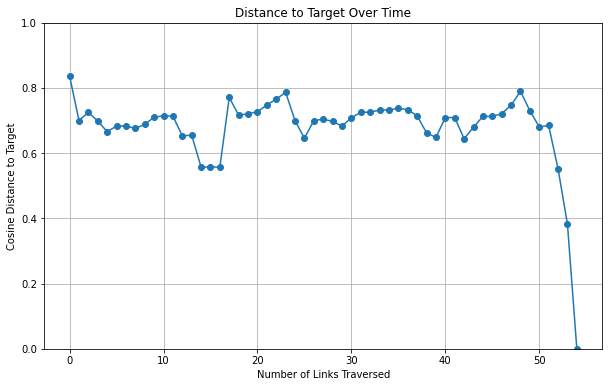



AI WINS! 🎉
Number of links traversed: 54
Total time taken: 29.632 seconds


In [59]:
origin_link = "https://en.wikipedia.org/wiki/Dark_matter"
dest_link = "https://en.wikipedia.org/wiki/Toilet"
check_links(origin_link, dest_link)
play(origin_link, dest_link)

GAME SETTINGS ⚙️
Origin: https://en.wikipedia.org/wiki/Black_hole
Destination: https://en.wikipedia.org/wiki/Barbie
Language: en
------------------------------------------------------------------------------------------------------------------------
CURRENT PAGE: https://en.wikipedia.org/wiki/Black_hole                              	Distance to target: 0.8300768741
CURRENT PAGE: https://en.wikipedia.org/wiki/Betty_Louise_Turtle                     	Distance to target: 0.7435334599
CURRENT PAGE: https://en.wikipedia.org/wiki/Robyn_Williams                          	Distance to target: 0.8009456523
CURRENT PAGE: https://en.wikipedia.org/wiki/Doctor_Who                              	Distance to target: 0.7509049462
CURRENT PAGE: https://en.wikipedia.org/wiki/Barbie_(film)                           	Distance to target: 0.0000000000
CURRENT PAGE: https://en.wikipedia.org/wiki/Barbie                                  	Distance to target: 0.0000000000
------------------------------------------

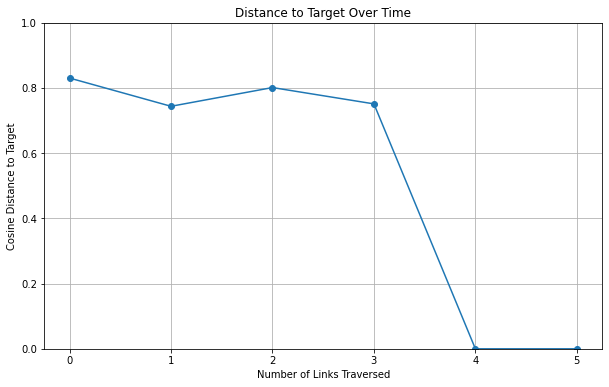



AI WINS! 🎉
Number of links traversed: 5
Total time taken: 3.993 seconds


In [60]:
origin_link = "https://en.wikipedia.org/wiki/Black_hole"
dest_link = "https://en.wikipedia.org/wiki/Barbie"
check_links(origin_link, dest_link)
play(origin_link, dest_link)